In [25]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.constants import c

In [26]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'figure.autolayout': True})

plt.rc('text', usetex=True)
plt.rc('font', family='serif',size=20)
plt.rc('font',size=30)
plt.rc('axes', linewidth=1.5) # change back to 1.5
plt.rc('axes', labelsize=20) # change back to 10
plt.rc('xtick', labelsize=18, direction='in')
plt.rc('ytick', labelsize=18, direction='in')
plt.rc('legend', fontsize=15) # change back to 7

# setting xtick parameters:

plt.rc('xtick.major',size=10,pad=4)
plt.rc('xtick.minor',size=5,pad=4)

plt.rc('ytick.major',size=10)
plt.rc('ytick.minor',size=5)

dpi = 600

In [27]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [7]:
dat_sec_1 = pd.read_csv('./inputs/larger_test_5000_1_deflector.csv').sort_values('redshift')
dat_sec_2 = pd.read_csv('./inputs/larger_test_5000_2_deflector.csv').sort_values('redshift')
dat_sec_3 = pd.read_csv('./inputs/larger_test_5000_3_deflector.csv').sort_values('redshift')
dat_sec_4 = pd.read_csv('./inputs/larger_test_5000_4_deflector.csv').sort_values('redshift')

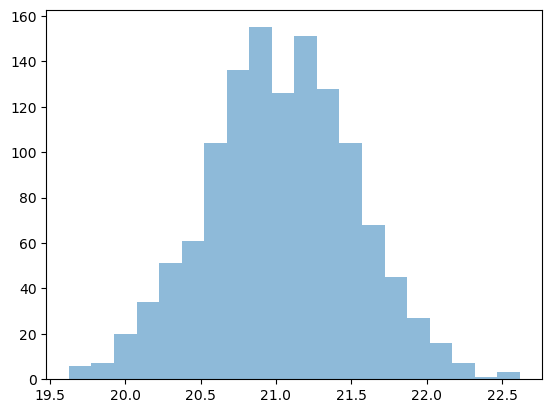

In [8]:
plt.hist(dat_sec_1['AB_magnitude'], bins=20, alpha=0.5, label='Section 1')
plt.show()

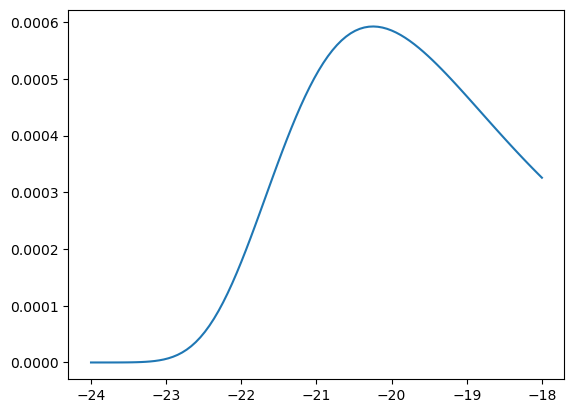

In [ ]:
def abs_M_scheter(M, M_star=-21.0, alpha=-0.5):
    return 0.4 * np.log(10) * 1.5e-3 * 10**(0.4*(alpha+1)*(M_star-M)) * np.exp(-10**(0.4*(M_star-M)))

M_values = np.linspace(-24, -18, 100)
schechter_values = abs_M_scheter(M_values)

plt.plot(M_values, schechter_values + )
plt.show()

In [10]:
DL = cosmo.luminosity_distance(dat_sec_1['redshift']).value  # in Mpc

mu = 5*np.log10(DL*1e6) - 5

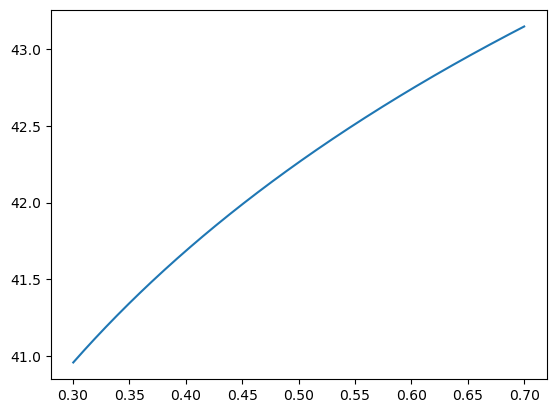

In [11]:
plt.plot(dat_sec_1['redshift'], mu)

In [12]:
import photometry

VIS_filter_passband = photometry.Passband(file='VIS.Euclid.pb')
VIS_filter = np.array([VIS_filter_passband.lam(unit=u.AA).value, VIS_filter_passband.y])

elliptical_SED = np.loadtxt('./inputs/SEDs/Ell13_template_norm.csv', unpack=True)

elliptical_SED.shape, VIS_filter.shape

((2, 1146), (2, 808))

In [13]:
from scipy.integrate import trapezoid

def redshift_sed(SED, z):
    return np.array([SED[0] * (1 + z), SED[1] / (1 + z)])


def get_weighted_mean_flux(SED, filter_throughput):
    interp_filter = np.interp(
        SED[0],
        filter_throughput[0],
        filter_throughput[1],
        left=0.0,
        right=0.0,
    )
    numerator = trapezoid(SED[1] * interp_filter * SED[0], SED[0])
    denominator = trapezoid(interp_filter * SED[0], SED[0])
    return numerator / denominator


def get_ab_magnitude(SED, filter_throughput):
    mean_flux = get_weighted_mean_flux(SED, filter_throughput)
    effective_wavelength = trapezoid(
        filter_throughput[0] * filter_throughput[1],
        filter_throughput[0],
    ) / trapezoid(filter_throughput[1], filter_throughput[0])
    f_nu = mean_flux * effective_wavelength ** 2 / c.to(u.AA / u.s).value
    return -2.5 * np.log10(f_nu) - 48.6


rest_vis_ab_mag = get_ab_magnitude(elliptical_SED, VIS_filter)


def vis_k_correction(z):
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    k_vals = np.array([
        get_ab_magnitude(redshift_sed(elliptical_SED, zi), VIS_filter) - rest_vis_ab_mag
        for zi in z_arr
    ])
    return k_vals[0] if np.ndim(z) == 0 else k_vals


all_redshifts = np.concatenate([
    dat_sec_1['redshift'].to_numpy(),
    dat_sec_2['redshift'].to_numpy(),
    dat_sec_3['redshift'].to_numpy(),
    dat_sec_4['redshift'].to_numpy(),
])
unique_redshifts = np.sort(np.unique(all_redshifts))
k_corrections_VIS = vis_k_correction(unique_redshifts)

for dataframe in [dat_sec_1, dat_sec_2, dat_sec_3, dat_sec_4]:
    dataframe['k_correction_VIS'] = vis_k_correction(dataframe['redshift'].to_numpy())

k_correction_table = pd.DataFrame({
    'redshift': unique_redshifts,
    'k_correction_VIS': k_corrections_VIS,
})

k_correction_table.head()

,redshift,k_correction_VIS
0,0.300026,0.290388
1,0.300074,0.290440
2,0.300174,0.290548
3,0.300183,0.290558
4,0.300242,0.290622


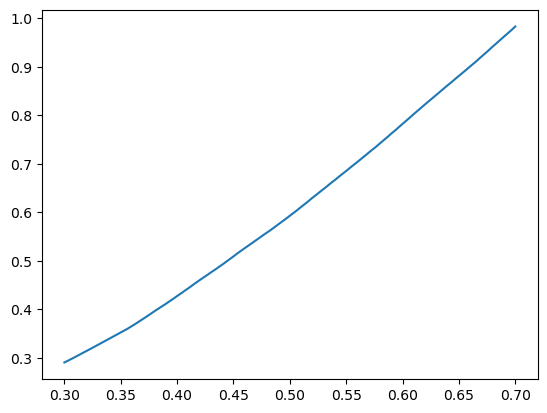

In [14]:
plt.plot(k_correction_table['redshift'], k_correction_table['k_correction_VIS'])

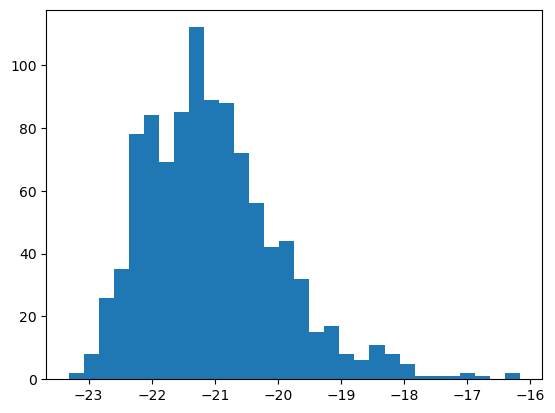

In [15]:
def sample_schechter(num_points=1, alpha=0.5, M_star=-21):

    k=alpha+1

    x = np.random.gamma(k, 1, num_points)

    return M_star - 2.5*np.log10(x)

plt.hist(sample_schechter(1000), bins=30)
plt.show()


In [17]:
from tqdm import tqdm
aparent_magnitude = []

for k_corr, mu_value in tqdm(zip(dat_sec_1['k_correction_VIS'], mu), total=len(mu)):
    M_value = 100
    while M_value + k_corr + mu_value > 22.5:
        M_value = sample_schechter(M_star=-23.5, alpha=-1.36)[0]

    aparent_magnitude.append(M_value + k_corr + mu_value)
    
#plt.plot(dat_sec_1['redshift'], aparent_magnitude, '.')
plt.hist(aparent_magnitude, bins=20)
plt.show()

  0%|          | 0/1250 [00:00<?, ?it/s]


ValueError: shape < 0

In [128]:
from skypy.galaxies.luminosity import schechter_lf_magnitude

zs = np.linspace(0.2, 0.9, 10000)

M = schechter_lf_magnitude(redshift=zs, M_star=-23.5, alpha=-1.36, m_lim=30, cosmology=cosmo)

app_M = M + vis_k_correction(zs) + 5*np.log10(cosmo.luminosity_distance(zs).value*1e6) - 5

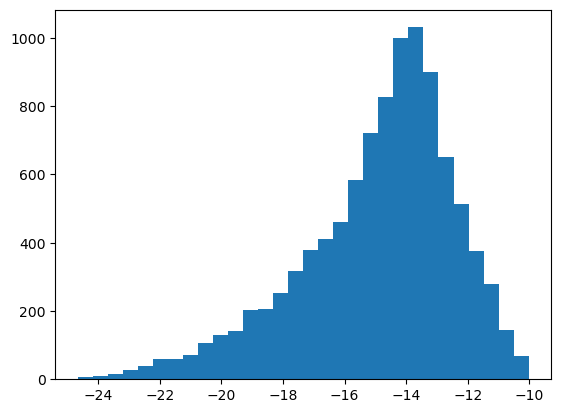

In [129]:
plt.hist(M, bins=30)
plt.show()

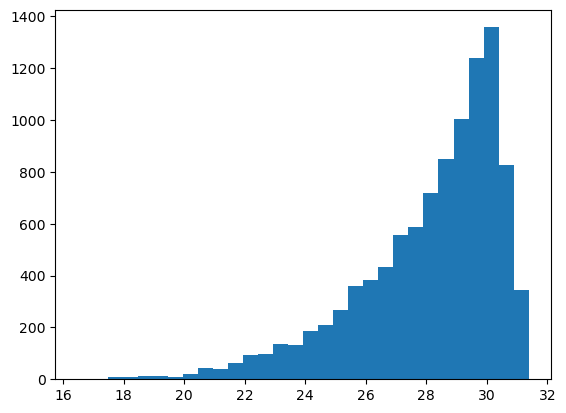

In [130]:
plt.hist(app_M, bins=30)
plt.show()

In [4]:
overall_deflector_params = pd.DataFrame()
overall_source_params = pd.DataFrame()

for i in range(1, 5):
    deflector_params = pd.read_csv(f'./inputs/full_run_rescaling_{i}_deflector.csv')
    source_params = pd.read_csv(f'./inputs/full_run_rescaling_{i}_source.csv')
    overall_deflector_params = pd.concat([overall_deflector_params, deflector_params], ignore_index=True)
    overall_source_params = pd.concat([overall_source_params, source_params], ignore_index=True)


overall_deflector_params.shape, overall_source_params.shape

((20000, 9), (20000, 8))

In [5]:
spec_z_conf_lenses = pd.read_csv('./csv_files/spec_conf_lens_db.csv')
spec_z_conf_lenses.shape

(720, 9)

In [10]:
np.median(deflector_params['redshift']), np.median(source_params['redshift'])


(0.5200072029089491, 2.156675174964632)

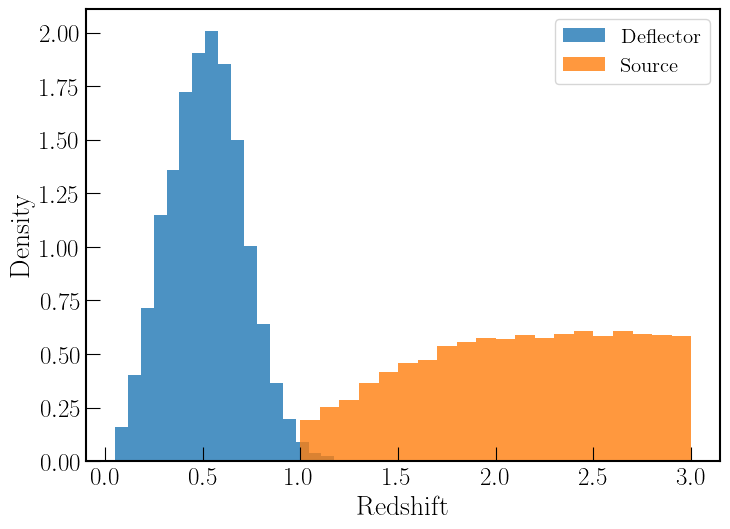

In [28]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 1, figsize=(8, 6))

axes.hist(overall_deflector_params['redshift'], bins=20, density=True, alpha=0.8, label='Deflector')
axes.hist(overall_source_params['redshift'], bins=20, density=True, alpha=0.8, label='Source')
axes.set_xlabel('Redshift')
axes.set_ylabel('Density')
axes.legend()



plt.savefig('./plots/z_dist.png', dpi=dpi)
plt.show()

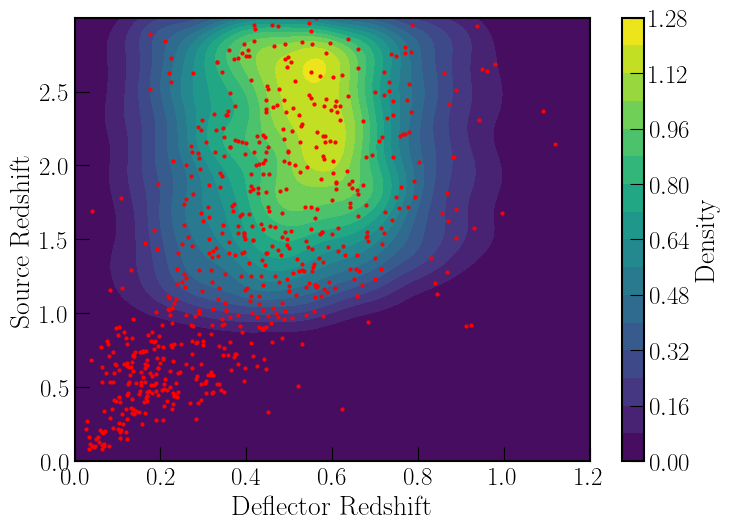

In [29]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))

# Density contour plot for the second axes
z_deflector = deflector_params['redshift'].to_numpy()
z_source = source_params['redshift'].to_numpy()

# Create a 2D grid for contouring
x = np.linspace(0.0, z_deflector.max(), 100)
y = np.linspace(0.0, z_source.max(), 100)
X, Y = np.meshgrid(x, y)

# Calculate density using gaussian_kde
xy = np.vstack([z_deflector, z_source])
positions = np.vstack([X.ravel(), Y.ravel()])
Z = gaussian_kde(xy)(positions).reshape(X.shape)

# Create contour plot
axes.contourf(X, Y, Z, levels=15, cmap='viridis')
axes.plot(spec_z_conf_lenses['z_def'], spec_z_conf_lenses['z_src'], '.', color='red', markersize=4)

axes.set_xlabel('Deflector Redshift')
axes.set_ylabel('Source Redshift')

axes.set_xlim(0.0, 1.2)
axes.set_ylim(0.0, z_source.max())

plt.colorbar(mappable=axes.collections[0], label='Density', ax=axes)

plt.savefig('./plots/z_contour.png', dpi=dpi)
plt.show()

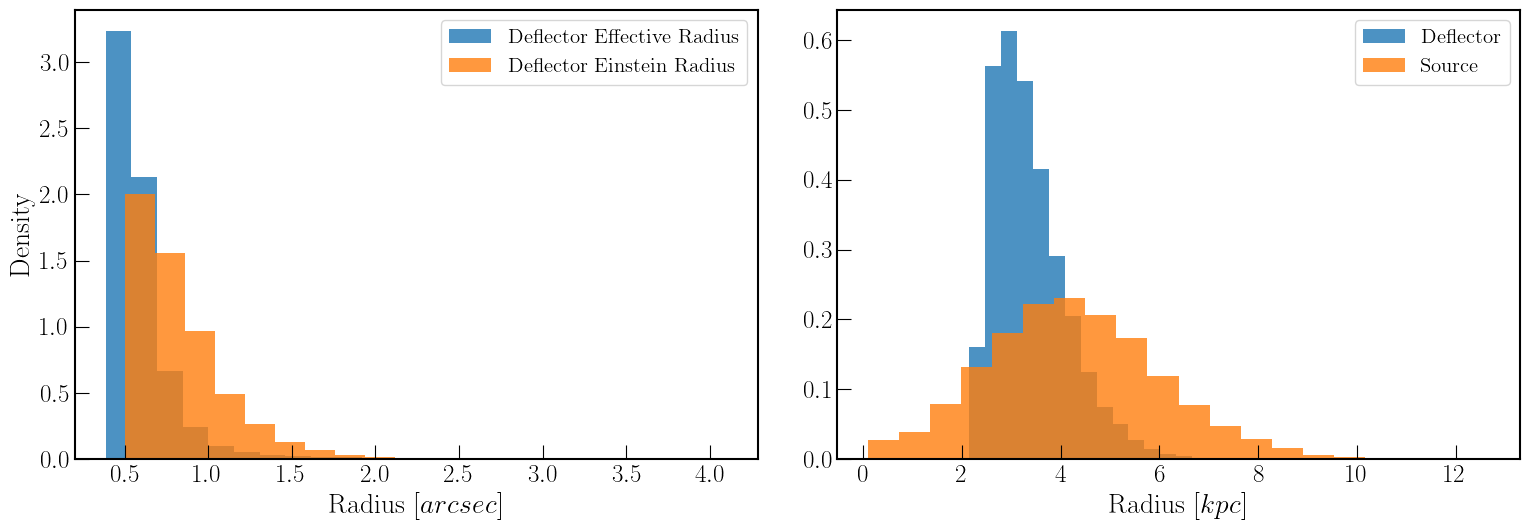

In [30]:
deflector_distances = cosmo.angular_diameter_distance(overall_deflector_params['redshift']).to(u.kpc).value

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(overall_deflector_params['effective_radius'] / deflector_distances * 206265, bins=20, density=True, label='Deflector Effective Radius', alpha=0.8)
axes[0].hist(overall_deflector_params['einstein_radius'], bins=20, density=True, label='Deflector Einstein Radius', alpha=0.8)

axes[0].set_xlabel(r'Radius $[arcsec]$')
axes[0].set_ylabel('Density')
axes[0].legend()


axes[1].hist(overall_deflector_params['effective_radius'], bins=20, density=True, label='Deflector', alpha=0.8)
axes[1].hist(overall_source_params['effective_radius'], bins=20, density=True, label='Source', alpha=0.8)

axes[1].set_xlabel(r'Radius $[kpc]$')
#axes[1].set_ylabel('Density')
axes[1].legend()

plt.savefig('./plots/radius_dist.png', dpi=dpi)
plt.show()

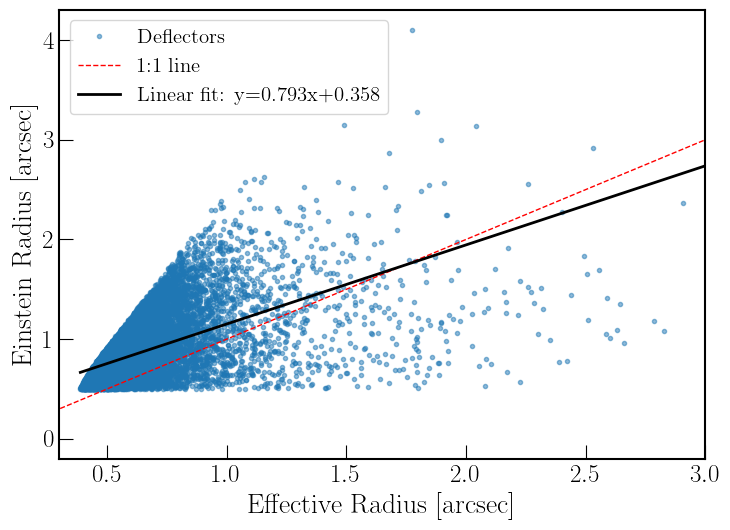

Slope:      0.793392 +/- 0.007818
Intercept:  0.358476 +/- 0.004955
Pearson r:  0.583012
R^2:        0.339903
p-value:    0.0
N points:   20000
20000


In [33]:
from scipy.stats import linregress

x_radius = overall_deflector_params['effective_radius'].to_numpy() / deflector_distances * 206265
y_einstein = overall_deflector_params['einstein_radius'].to_numpy()

# Remove non-finite points before regression
valid = np.isfinite(x_radius) & np.isfinite(y_einstein)
x_fit = x_radius[valid]
y_fit = y_einstein[valid]

reg = linregress(x_fit, y_fit)
y_pred = reg.slope * x_fit + reg.intercept

plt.figure(figsize=(8, 6))
plt.plot(x_fit, y_fit, '.', alpha=0.5, label='Deflectors')
plt.plot([0.0, 3.0], [0.0, 3.0], 'r--', lw=1, label='1:1 line')
plt.plot(
    np.sort(x_fit),
    reg.slope * np.sort(x_fit) + reg.intercept,
    color='black',
    lw=2,
    label=f'Linear fit: y={reg.slope:.3f}x+{reg.intercept:.3f}'
)

plt.xlabel('Effective Radius [arcsec]')
plt.ylabel('Einstein Radius [arcsec]')
plt.xlim(0.3, 3.0)
#plt.ylim(0.0, max(3.0, np.nanmax(y_fit) * 1.05))
plt.legend()

plt.savefig('./plots/radius_comparison.png', dpi=dpi)
plt.show()

ss_res = np.sum((y_fit - y_pred) ** 2)
ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f'Slope:      {reg.slope:.6f} +/- {reg.stderr:.6f}')
print(f'Intercept:  {reg.intercept:.6f} +/- {reg.intercept_stderr:.6f}')
print(f'Pearson r:  {reg.rvalue:.6f}')
print(f'R^2:        {r2:.6f}')
print(f'p-value:    {reg.pvalue}')
print(f'N points:   {len(x_fit)}')
print(len(overall_deflector_params['effective_radius']))

In [16]:
from scipy.optimize import curve_fit

# Schechter luminosity function in magnitude form, scaled to histogram counts
def schechter_counts(mag, phi_star, M_star, alpha, bin_width):
    phi_M = (
        0.4 * np.log(10) * phi_star
        * 10 ** (-0.4 * (mag - M_star) * (alpha + 1.0))
        * np.exp(-10 ** (-0.4 * (mag - M_star)))
    )
    return phi_M * bin_width

mags = deflector_params['AB_magnitude'].dropna().to_numpy()

# Bin magnitudes and fit model to binned counts
n_bins = 20
counts, bin_edges = np.histogram(mags, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Poisson-like uncertainties for weighted least squares
sigma = np.sqrt(np.maximum(counts, 1.0))

# Initial guesses and bounds: phi_star > 0, alpha < 0 for a typical LF
p0 = [counts.max(), np.median(mags), -1.0]
bounds = ([1e-12, mags.min() - 3.0, -3.0], [1e8, mags.max() + 3.0, -0.01])

popt, pcov = curve_fit(
    lambda m, phi_star, M_star, alpha: schechter_counts(m, phi_star, M_star, alpha, bin_width),
    bin_centers,
    counts,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=50000,
    )

phi_star_fit, M_star_fit, alpha_fit = popt
perr = np.sqrt(np.diag(pcov))

# Plot binned counts and best-fit Schechter model
x_plot = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_plot = schechter_counts(x_plot, phi_star_fit, M_star_fit, alpha_fit, bin_width)

model_counts = schechter_counts(bin_centers, phi_star_fit, M_star_fit, alpha_fit, bin_width)
residuals = counts - model_counts

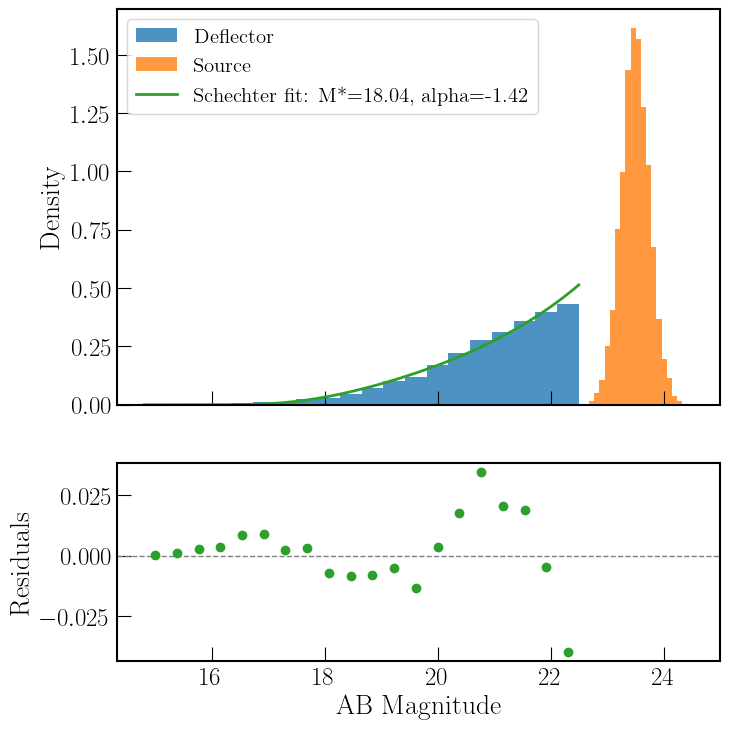

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].hist(deflector_params['AB_magnitude'], bins=20, density=True, alpha=0.8, label='Deflector')
axes[0].hist(source_params['AB_magnitude'], bins=20, density=True, alpha=0.8, label='Source')
axes[0].plot(
    x_plot,
    y_plot/np.trapz(y_plot, x_plot),
    '-',
    lw=2,
    label=f'Schechter fit: M*={M_star_fit:.2f}, alpha={alpha_fit:.2f}'
)
#axes[0].set_xlabel('AB Magnitude')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].axhline(0.0, color='gray', ls='--', lw=1)
axes[1].plot(bin_centers, residuals/np.trapz(y_plot, x_plot), 'o', color='C2', label='Residuals')
axes[1].set_xlabel('AB Magnitude')
axes[1].set_ylabel('Residuals')

plt.savefig('./plots/magnitude_dist.png', dpi=dpi)
plt.show()

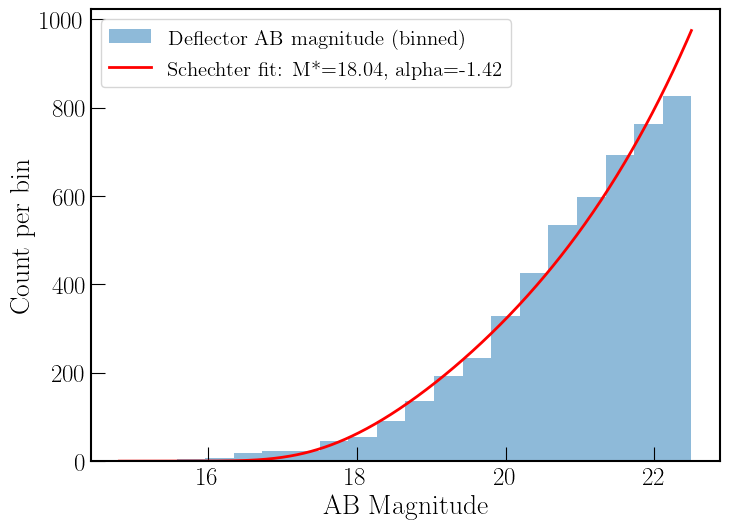

Best fit phi*: 5.0366e+02 +/- 5.6172e+01
Best fit M*:   18.0416 +/- 0.1105
Best fit alpha:-1.4174 +/- 0.0219


In [ ]:
from scipy.optimize import curve_fit

# Schechter luminosity function in magnitude form, scaled to histogram counts
def schechter_counts(mag, phi_star, M_star, alpha, bin_width):
    phi_M = (
        0.4 * np.log(10) * phi_star
        * 10 ** (-0.4 * (mag - M_star) * (alpha + 1.0))
        * np.exp(-10 ** (-0.4 * (mag - M_star)))
    )
    return phi_M * bin_width

mags = deflector_params['AB_magnitude'].dropna().to_numpy()

# Bin magnitudes and fit model to binned counts
n_bins = 20
counts, bin_edges = np.histogram(mags, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Poisson-like uncertainties for weighted least squares
sigma = np.sqrt(np.maximum(counts, 1.0))

# Initial guesses and bounds: phi_star > 0, alpha < 0 for a typical LF
p0 = [counts.max(), np.median(mags), -1.0]
bounds = ([1e-12, mags.min() - 3.0, -3.0], [1e8, mags.max() + 3.0, -0.01])

popt, pcov = curve_fit(
    lambda m, phi_star, M_star, alpha: schechter_counts(m, phi_star, M_star, alpha, bin_width),
    bin_centers,
    counts,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=50000,
    )

phi_star_fit, M_star_fit, alpha_fit = popt
perr = np.sqrt(np.diag(pcov))

# Plot binned counts and best-fit Schechter model
x_plot = np.linspace(bin_edges[0], bin_edges[-1], 500)
y_plot = schechter_counts(x_plot, phi_star_fit, M_star_fit, alpha_fit, bin_width)

plt.figure(figsize=(8, 6))
plt.hist(mags, bins=bin_edges, alpha=0.5, label='Deflector AB magnitude (binned)')
plt.plot(
    x_plot,
    y_plot,
    'r-',
    lw=2,
    label=f'Schechter fit: M*={M_star_fit:.2f}, alpha={alpha_fit:.2f}'
)
plt.xlabel('AB Magnitude')
plt.ylabel('Count per bin')
plt.legend()
plt.show()

print(f"Best fit phi*: {phi_star_fit:.4e} +/- {perr[0]:.4e}")
print(f"Best fit M*:   {M_star_fit:.4f} +/- {perr[1]:.4f}")
print(f"Best fit alpha:{alpha_fit:.4f} +/- {perr[2]:.4f}")

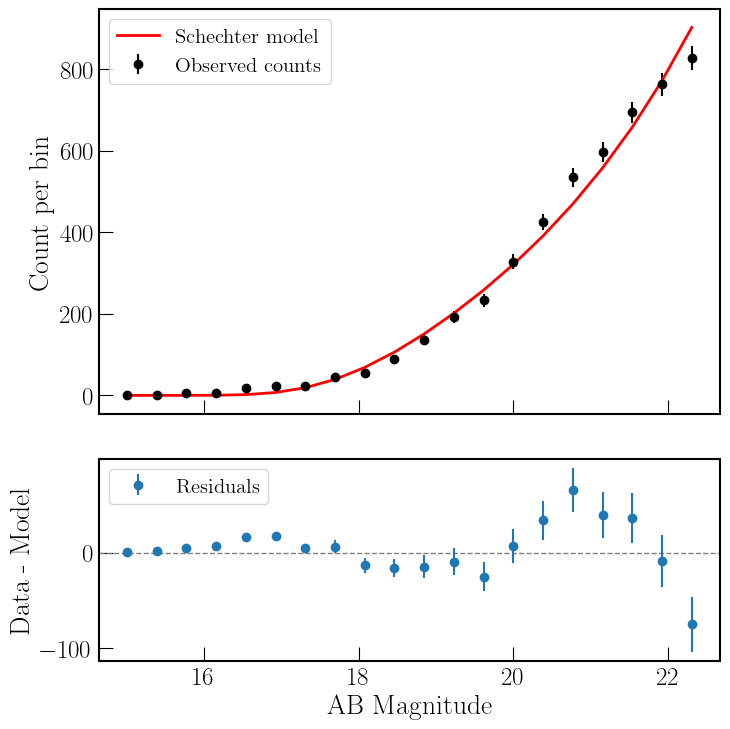

Reduced chi^2: 4.462


In [ ]:
# Residuals: observed binned counts - Schechter model prediction
model_counts = schechter_counts(bin_centers, phi_star_fit, M_star_fit, alpha_fit, bin_width)
residuals = counts - model_counts
norm_residuals = residuals / sigma

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].errorbar(bin_centers, counts, yerr=sigma, fmt='o', color='black', label='Observed counts')
axes[0].plot(bin_centers, model_counts, 'r-', lw=2, label='Schechter model')
axes[0].set_ylabel('Count per bin')
axes[0].legend()

axes[1].axhline(0.0, color='gray', ls='--', lw=1)
axes[1].errorbar(bin_centers, residuals, yerr=sigma, fmt='o', color='tab:blue', label='Residuals')
axes[1].set_xlabel('AB Magnitude')
axes[1].set_ylabel('Data - Model')
axes[1].legend()

plt.tight_layout()
plt.show()

chi2 = np.sum((residuals / sigma) ** 2)
dof = len(counts) - 3
print(f'Reduced chi^2: {chi2 / dof:.3f}')

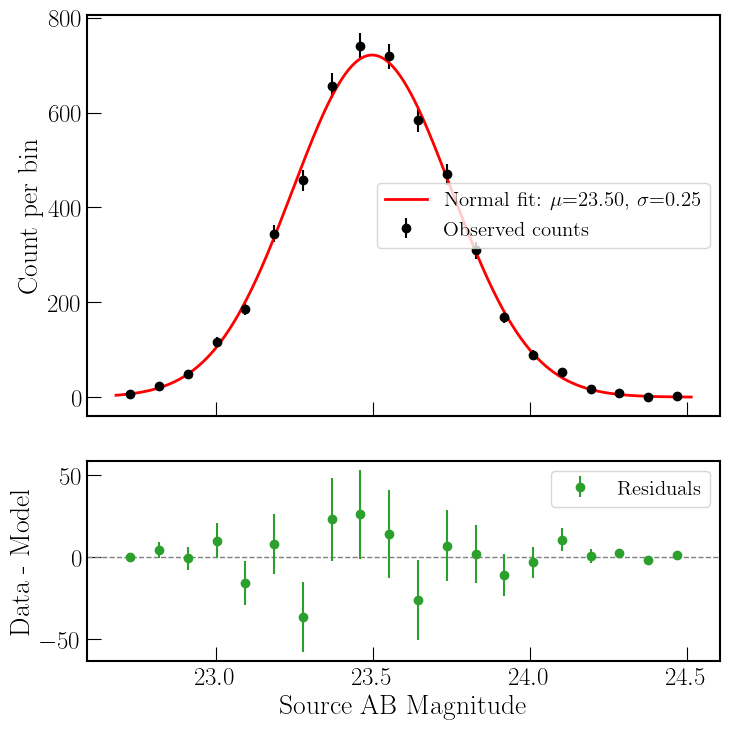

Normal fit A:      4.9875e+03 +/- 7.0658e+01
Normal fit mu:     23.4982 +/- 0.0036
Normal fit sigma:  0.2526 +/- 0.0026
Reduced chi^2:     1.015


In [18]:
from scipy.stats import norm
from scipy.optimize import curve_fit

# Fit a normal distribution to binned source AB magnitudes (count space)
source_mags = source_params['AB_magnitude'].dropna().to_numpy()

n_bins_source = 20
source_counts, source_bin_edges = np.histogram(source_mags, bins=n_bins_source)
source_bin_centers = 0.5 * (source_bin_edges[:-1] + source_bin_edges[1:])
source_bin_width = source_bin_edges[1] - source_bin_edges[0]

# Poisson-like uncertainties for binned counts
source_sigma = np.sqrt(np.maximum(source_counts, 1.0))

# Model: expected counts per bin from a Gaussian shape
def gaussian_counts(mag, A, mu, sigma_g, bin_width):
    return A * norm.pdf(mag, loc=mu, scale=sigma_g) * bin_width

p0_source = [len(source_mags), np.mean(source_mags), np.std(source_mags)]
bounds_source = ([1e-8, source_mags.min() - 1.0, 1e-6], [1e8, source_mags.max() + 1.0, 10.0])

popt_source, pcov_source = curve_fit(
    lambda m, A, mu, sigma_g: gaussian_counts(m, A, mu, sigma_g, source_bin_width),
    source_bin_centers,
    source_counts,
    p0=p0_source,
    sigma=source_sigma,
    absolute_sigma=True,
    bounds=bounds_source,
    maxfev=50000,
    )

A_fit_source, mu_fit_source, sigma_fit_source = popt_source
perr_source = np.sqrt(np.diag(pcov_source))

source_model_counts = gaussian_counts(
    source_bin_centers,
    A_fit_source,
    mu_fit_source,
    sigma_fit_source,
    source_bin_width,
    )
source_residuals = source_counts - source_model_counts

x_plot_source = np.linspace(source_bin_edges[0], source_bin_edges[-1], 500)
y_plot_source = gaussian_counts(
    x_plot_source,
    A_fit_source,
    mu_fit_source,
    sigma_fit_source,
    source_bin_width,
    )

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].errorbar(source_bin_centers, source_counts, yerr=source_sigma, fmt='o', color='black', label='Observed counts')
axes[0].plot(x_plot_source, y_plot_source, 'r-', lw=2, label=f'Normal fit: $\\mu$={mu_fit_source:.2f}, $\\sigma$={sigma_fit_source:.2f}')
axes[0].set_ylabel('Count per bin')
axes[0].legend()

axes[1].axhline(0.0, color='gray', ls='--', lw=1)
axes[1].errorbar(source_bin_centers, source_residuals, yerr=source_sigma, fmt='o', color='tab:green', label='Residuals')
axes[1].set_xlabel('Source AB Magnitude')
axes[1].set_ylabel('Data - Model')
axes[1].legend()

plt.tight_layout()
plt.show()

chi2_source = np.sum((source_residuals / source_sigma) ** 2)
dof_source = len(source_counts) - 3
print(f'Normal fit A:      {A_fit_source:.4e} +/- {perr_source[0]:.4e}')
print(f'Normal fit mu:     {mu_fit_source:.4f} +/- {perr_source[1]:.4f}')
print(f'Normal fit sigma:  {sigma_fit_source:.4f} +/- {perr_source[2]:.4f}')
print(f'Reduced chi^2:     {chi2_source / dof_source:.3f}')

In [6]:
# load euclid candidate catalogue

euclid_lens_df = pd.read_csv('/Users/admin/Documents/euclid/catalogues/q1_discovery_engine_lens_catalog.csv')
euclid_object_cut = pd.read_csv('./csv_files/MER_22_5_cut_w_tile_id_and_flux-result.csv')

In [7]:
euclid_lens_df['ab_mag'] = -2.5 * np.log10(euclid_lens_df['flux_vis_1fwhm_aper']*1e-6/3631)
euclid_object_cut['ab_mag_4fwhm'] = -2.5 * np.log10(euclid_object_cut['flux_vis_4fwhm_aper']*1e-6/3631)
euclid_object_cut['ab_mag_1fwhm'] = -2.5 * np.log10(euclid_object_cut['flux_vis_1fwhm_aper']*1e-6/3631)

/Users/admin/miniforge3/envs/lenstronomy/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


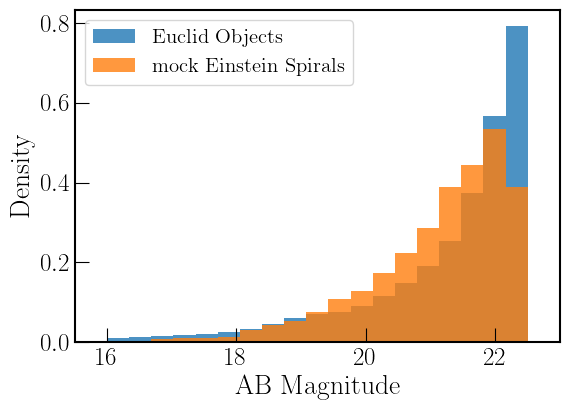

In [9]:
bins = np.linspace(16, 22.5, 20)

plt.hist((euclid_object_cut['ab_mag_4fwhm']), bins=bins, density=True, alpha=0.8, label='Euclid Objects')
#plt.hist(euclid_lens_df['ab_mag'], bins=20, density=True, alpha=0.8, label='Euclid Candidates')
total_mags = -2.5*np.log10((10**(-0.4*(overall_deflector_params['AB_magnitude'])) + 10**(-0.4*source_params['AB_magnitude'])))

plt.hist(total_mags+(22.5-np.max(total_mags)), bins=bins, density=True, alpha=0.8, label='mock Einstein Spirals')
plt.xlabel('AB Magnitude')
plt.ylabel('Density')
plt.xlim(15.5, 23)
plt.legend()

plt.savefig('./plots/magnitude_comparison.png', dpi=dpi)
plt.show()